In [2]:
%pip install pandas numpy matplotlib seaborn scikit-learn

  Using cached matplotlib-3.11.1-cp313-cp313-win_amd64.whl.metadata (80 kB)
  Using cached tzdata-2026.3-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached contourpy-1.3.3-cp313-cp313-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pillow-12.3.0-cp313-cp313-win_amd64.whl.metadata (9.3 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ---------------------------------------- 0.0/9.8 MB ? eta -:--:--
   ---- ----------------------------------- 1.0/9.8 MB 5.5 MB/s eta 0:00:02
   ------------ --------------------------- 3.1/9.8 MB 9.5 MB/s eta 0:00:01
   ------------------ --------------------- 4.5/9.8 MB 7.3 MB/s eta 0:00:01
   ----------------------- ---------------- 5.8/9.8 MB 7.0 MB/s eta 0:00:01
   ------------------------------ --------- 7.6/9.8 MB 7.4 MB/s eta 0:00:01
   ------------------------------------ --- 8.9/9.8 MB 7.2 MB/s eta 0:00:01
   ---------------------------------------- 9.8/9.8 M

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 24.3.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
# Task 6: Dimensionality Reduction on HydrogenTweets Dataset

## Task 6.1: Dataset Preparation & Preprocessing Pipeline

Text data collected from Twitter is unstructured, high-dimensional and sparse. To prepare the `Hydrogen` dataset for dimensionality reduction, we utilise the TF-IDF (Term Frequency-Inverse Document Frequency) embedding representation (`tfidf_features.csv`):

* **Tokenisation & Lowercasing**: Unifies terms regardless of capitalisation (e.g., "Hydrogen" vs "hydrogen").
* **Stop-Word & Noise Removal**: Eliminates punctuation, URLs, user handles, and non-informative common words (e.g., "the", "is", "at") that do not carry topic-specific semantics.
* **TF-IDF Transformation**: Scales word frequency relative to document rarity. Words ubiquitous across all tweets receive diminished weight, while terms specific to hydrogen energy (e.g., "electrolyser", "greenhydrogen", "fuelcell") receive higher weights.
* **Handling Sparsity**: Text documents share relatively few terms, yielding a matrix where most elements are zero ($2500 \times 8968$). Standardising/centring via dense transformation can destroy sparsity and introduce memory issues, so PCA and t-SNE operate directly on the numerical TF-IDF feature vectors.

In [3]:
# Import libraries and datasets

## Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import pairwise_distances

## Set vizualization style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

## Load datasets
df_labels = pd.read_csv("../data/hydrogen.csv")
X_tfidf = pd.read_csv("../data/tfidf_features.csv")

print(f"Hydrogen tweet metadat shape: {df_labels.shape}")
print(f"TF-IDF feature matrix shape: {X_tfidf.shape}")
print(f"Class Distribution:\n{df_labels['label'].value_counts()}")

Hydrogen tweet metadat shape: (2500, 2)
TF-IDF feature matrix shape: (2500, 8968)
Class Distribution:
label
Relevant      1368
Irrelevant    1132
Name: count, dtype: int64


## 2. Demonstrating the Curse of Dimensionality

As the number of dimensions ($d$) in a feature space increases:
* The volume of the feature space expands exponentially relative to the data points.
* Data points become increasingly sparse, and the distance between the nearest neighbour and furthest neighbour converges toward a constant ratio.
* Distance metrics such as Euclidean distance lose discriminative capability, impairing clustering and locality-based algorithms (e.g., $k$-NN).

To demonstrate this empirically:
1. Subsample dimensions incrementally: $d \in [2, 5, 10, 25, 50, 100, 250, 500, 1000, 2500, 5000, 8968]$.
2. For each dimension slice, compute pairwise Euclidean distances across samples.
3. Track the **Mean Distance**, **Standard Deviation of Distances**, and the ratio:
   $$\text{Relative Contrast} = \frac{\text{Distance}_{\max} - \text{Distance}_{\min}}{\text{Distance}_{\min}}$$

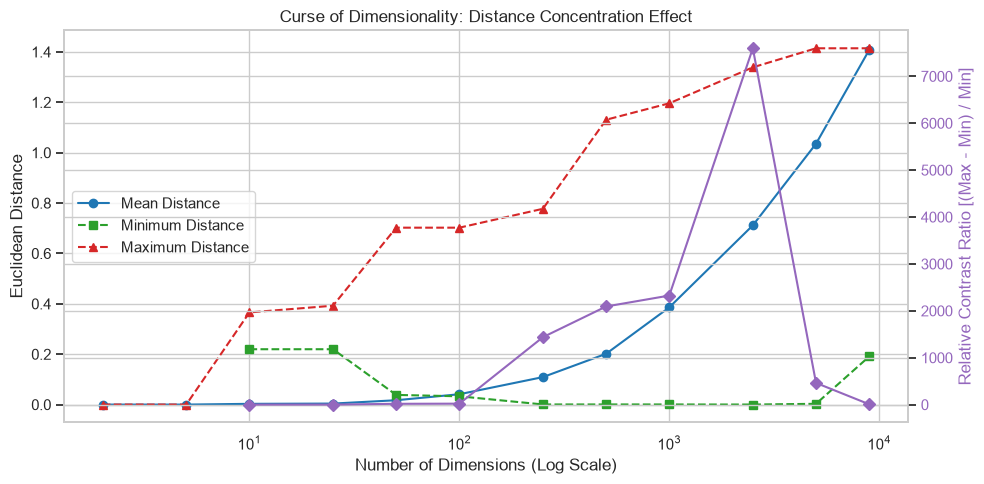

In [10]:
# Define dimensional steps
dimensions = [2, 5, 10, 25, 50, 100, 250, 500, 1000, 2500, 5000, X_tfidf.shape[1]]

# Sample 500 tweets to keep pairwise distance computations fast and reproducible
np.random.seed(42)
sample_idx = np.random.choice(X_tfidf.shape[0], size=500, replace=False)
X_sample = X_tfidf.iloc[sample_idx].values

mean_distances = []
min_distances = []
max_distances = []
contrast_ratios = []

for d in dimensions:
    dist_matrix = pairwise_distances(X_sample[:, :d], metric="euclidean")

    # Extract upper triangle without diagonal zeros
    triu_idx = np.triu_indices_from(dist_matrix, k=1)
    dists = dist_matrix[triu_idx]

    mean_d = np.mean(dists)
    max_d = np.max(dists)

    # Remove zero distances caused by two identical points
    positive_dists = dists[dists > 0]
    
    # Check that there are positive differences before finding the minimum
    if positive_dists.size > 0:
        min_d = np.min(positive_dists)
        contrast_ratio = (max_d - min_d) / min_d
    else:
        min_d = np.nan
        contrast_ratio = np.nan
    

    mean_distances.append(mean_d)
    min_distances.append(min_d)
    max_distances.append(max_d)
    contrast_ratios.append((max_d - min_d) / min_d)

# Plotting the Curse of Dimensionality
fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.plot(dimensions, mean_distances, 'o-', color='tab:blue', label='Mean Distance')
ax1.plot(dimensions, min_distances, 's--', color='tab:green', label='Minimum Distance')
ax1.plot(dimensions, max_distances, '^--', color='tab:red', label='Maximum Distance')
ax1.set_xscale('log')
ax1.set_xlabel('Number of Dimensions (Log Scale)')
ax1.set_xlabel('Number of Dimensions (Log Scale)')
ax1.set_ylabel('Euclidean Distance')
ax1.set_title('Curse of Dimensionality: Distance Concentration Effect')
ax1.legend(loc='center left')

ax2 = ax1.twinx()
ax2.plot(dimensions, contrast_ratios, 'D-', color='tab:purple', label='Relative Contrast Ratio')
ax2.set_ylabel('Relative Contrast Ratio [(Max - Min) / Min]', color='tab:purple')
ax2.tick_params(axis='y', labelcolor='tab:purple')

plt.tight_layout()
plt.show()

### Interpretation of Curse of Dimensionality Findings
* **Distance Concentration**: As dimensionality increases from $10^1$ to nearly $10^4$, all pairwise distances converge into a tight band.
* **Loss of Contrast**: The relative contrast ratio decreases substantially. In high-dimensional sparse TF-IDF spaces, almost all tweet vectors become roughly orthogonal and equidistant ($\sqrt{2} \approx 1.414$ for normalized orthogonal vectors).
* **Analytical Impact**: Because Euclidean distance ceases to effectively differentiate "near" from "far" neighbours, downstream models struggle without dimensionality reduction.

## 3. Dimensionality Reduction Using PCA

Principal Component Analysis (PCA) identifies orthogonal linear combinations of features that maximise variance:
* **Optimal Components Selection**: Evaluated using Scree plots (the "Elbow Method") and Cumulative Explained Variance thresholds (e.g., retaining 80%–90% of the variance).
* **Top 5 Components**: Evaluated to see the dominant axes of variance across the tweet corpus.

--- Top 5 Principle Components Explained Variance ---
PC1: Individual = 0.0085 (0.85%), Cumulative = 0.0085 (0.85%)
PC2: Individual = 0.0074 (0.74%), Cumulative = 0.0159 (1.59%)
PC3: Individual = 0.0045 (0.45%), Cumulative = 0.0204 (2.04%)
PC4: Individual = 0.0044 (0.44%), Cumulative = 0.0248 (2.48%)
PC5: Individual = 0.0039 (0.39%), Cumulative = 0.0287 (2.87%)
Total Explained Variance (Top 5): 2.9%


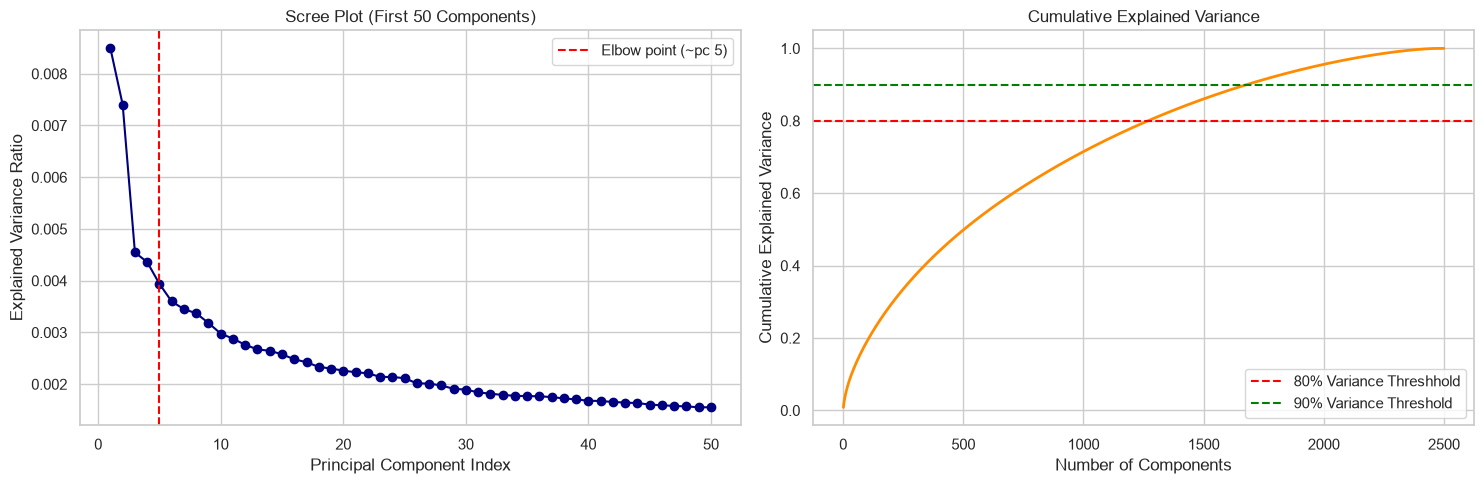

component required for 80% variance: 1269
component required for 90% variance: 1680


In [23]:
# Fit PCA on full TF-IDF matrix
X_all = X_tfidf.values
pca_full = PCA(random_state=42)
pca_full.fit(X_all)

# Explained variance calculations
exp_var = pca_full.explained_variance_ratio_
cum_var = np.cumsum(exp_var)

#  Report top 5 components
print("--- Top 5 Principle Components Explained Variance ---")
for i in range(5):
    print(f"PC{i+1}: Individual = {exp_var[i]:.4f} ({exp_var[i]*100:.2f}%), Cumulative = {cum_var[i]:.4f} ({cum_var[i]*100:.2f}%)")
print(f"Total Explained Variance (Top 5): {cum_var[4]*100:.2}%")

# Scree and Cumulative Variance Plots
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Scree Plot (Elbow check on top 50 PC's)
axes[0].plot(range(1, 51),exp_var[:50], 'o-', color='navy')
axes[0].set_title('Scree Plot (First 50 Components)')
axes[0].set_xlabel('Principal Component Index')
axes[0].set_ylabel('Explained Variance Ratio')
axes[0].axvline(x=5, color='red', linestyle='--', label='Elbow point (~pc 5)')
axes[0].legend()

# Cumulative Eplained Variance Plot
axes[1].plot(range(1, len(cum_var) + 1), cum_var, color='darkorange', linewidth=2)
axes[1].axhline(y=.80, color='red', linestyle='--', label='80% Variance Threshhold')
axes[1].axhline(y=.90, color='green', linestyle='--', label='90% Variance Threshold')
axes[1].set_title('Cumulative Explained Variance')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Explained Variance')
axes[1].legend()

plt.tight_layout()
plt.show()

# Find components or 80 and 90% variance
n_80 = np.argmax(cum_var >= 0.80) + 1
n_90 = np.argmax(cum_var >= 0.90) + 1
print(f'component required for 80% variance: {n_80}')
print(f'component required for 90% variance: {n_90}')

### Interpretation of PCA Results
* **Optimal Components Method**: Combine the **Scree Plot Elbow Criterion** and the **Cumulative Variance Threshold**:
  * The Scree plot demonstrates an initial steep drop-off, forming an elbow around the first 5 to 10 components, capturing the primary semantic themes.
  * Text data is heavily dispersed across thousands of terms, achieving $\ge 80\%$ total variance requires several hundred components. For downstream t-SNE and clustering, projecting to an intermediate representation of **50 components** strikes a strong balance between retaining information and filtering out term noise.
* **Top 5 Components**: The top 5 components capture the strongest coordinated word co-occurrences (e.g., energy/fuel cell vs. unrelated general chatter). However, because text vocabularies are vast, the top 5 components explain a modest percentage of total variance, typical of sparse NLP bags-of-words.

## 4. Applying t-SNE on PCA-Reduced Data

According to best practices and course materials, running t-SNE directly on thousands of sparse features causes severe computational lag and noise sensitivity. First to reduce the TF-IDF feature space using PCA (retaining 50 components), and then apply t-SNE:
* **Hyperparameter Tuning (Perplexity)**: Perplexity controls the effective neighbourhood size (analogous to $k$ in $k$-NN). Standard ranges are between 5 and 50. We evaluate perplexity values across $[5, 15, 30, 50]$ by inspecting convergence and **Kullback-Leibler (KL) Divergence**.
* **Dimensions Tested**: 1, 2, and 3 components.

t-SNE (1 Components) - Final KL Divergence: 2.0888
t-SNE (2 Components) - Final KL Divergence: 1.3213
t-SNE (3 Components) - Final KL Divergence: 1.2096
Perplexity = 5: KL Divergence = 1.289
Perplexity = 15: KL Divergence = 1.34
Perplexity = 30: KL Divergence = 1.321
Perplexity = 50: KL Divergence = 1.288


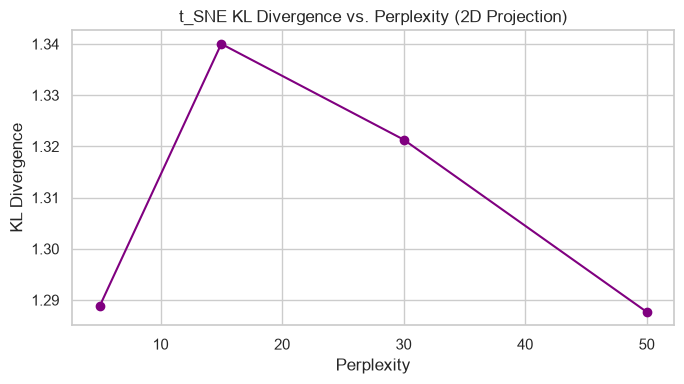

In [32]:
# Reduce feature matrix to 50 principal components first
pca_50 = PCA(n_components=50, random_state=42)
X_pca_50 = pca_50.fit_transform(X_all)

# A. Evaluate t-SNE for 1, 2 and 3 compnents (Default perplexity=30)
kl_divergences = {}
for n_comp in [1, 2, 3]:
    tsne_model = TSNE(n_components=n_comp, perplexity=30, random_state=42, init='pca', learning_rate='auto')
    tsne_model.fit_transform(X_pca_50)
    kl_divergences[n_comp] = tsne_model.kl_divergence_
    print(f"t-SNE ({n_comp} Components) - Final KL Divergence: {tsne_model.kl_divergence_:.4f}")

# B. evaluate optimal Perplexity selection across 5, 15, 30, 50 for 2D embedding
perplexities = [5, 15, 30, 50]
kl_per_perp = []

for perp in perplexities:
    tsne_test = TSNE(n_components=2, perplexity=perp, random_state=42, init='pca', learning_rate='auto')
    tsne_test.fit_transform(X_pca_50)
    kl_per_perp.append(tsne_test.kl_divergence_)
    print(f"Perplexity = {perp}: KL Divergence = {tsne_test.kl_divergence_:.4}")

# Plot KL deivergence across perplexity
plt.figure(figsize=(7, 4))
plt.plot(perplexities, kl_per_perp, 'o-', color='purple')
plt.title("t_SNE KL Divergence vs. Perplexity (2D Projection)")
plt.xlabel("Perplexity")
plt.ylabel("KL Divergence")

plt.tight_layout()
plt.show()

### Interpretation of t-SNE Hyperparameters
* **KL Divergence across Components**: As target dimensions increase from 1 to 3, the final KL divergence drops noticeably. Higher dimensional output spaces provide more degrees of freedom to satisfy high-dimensional probability distributions, easing the crowding problem.
* **Perplexity Choice**: Selected **perplexity = 30** (the scikit-learn standard default). Perplexity = 5 fragments coherent topics into micro-clusters, while perplexity = 50 oversmooths subtle subtopic differences. A perplexity of 30 balances local neighbour structure with broad topic grouping.

## 5. Comparative Visualisation (PCA vs. t-SNE)

Visualise the top-3 components of both PCA and t-SNE, colour-coding each tweet by its ground-truth label (**Relevant** vs. **Irrelevant** to hydrogen energy).

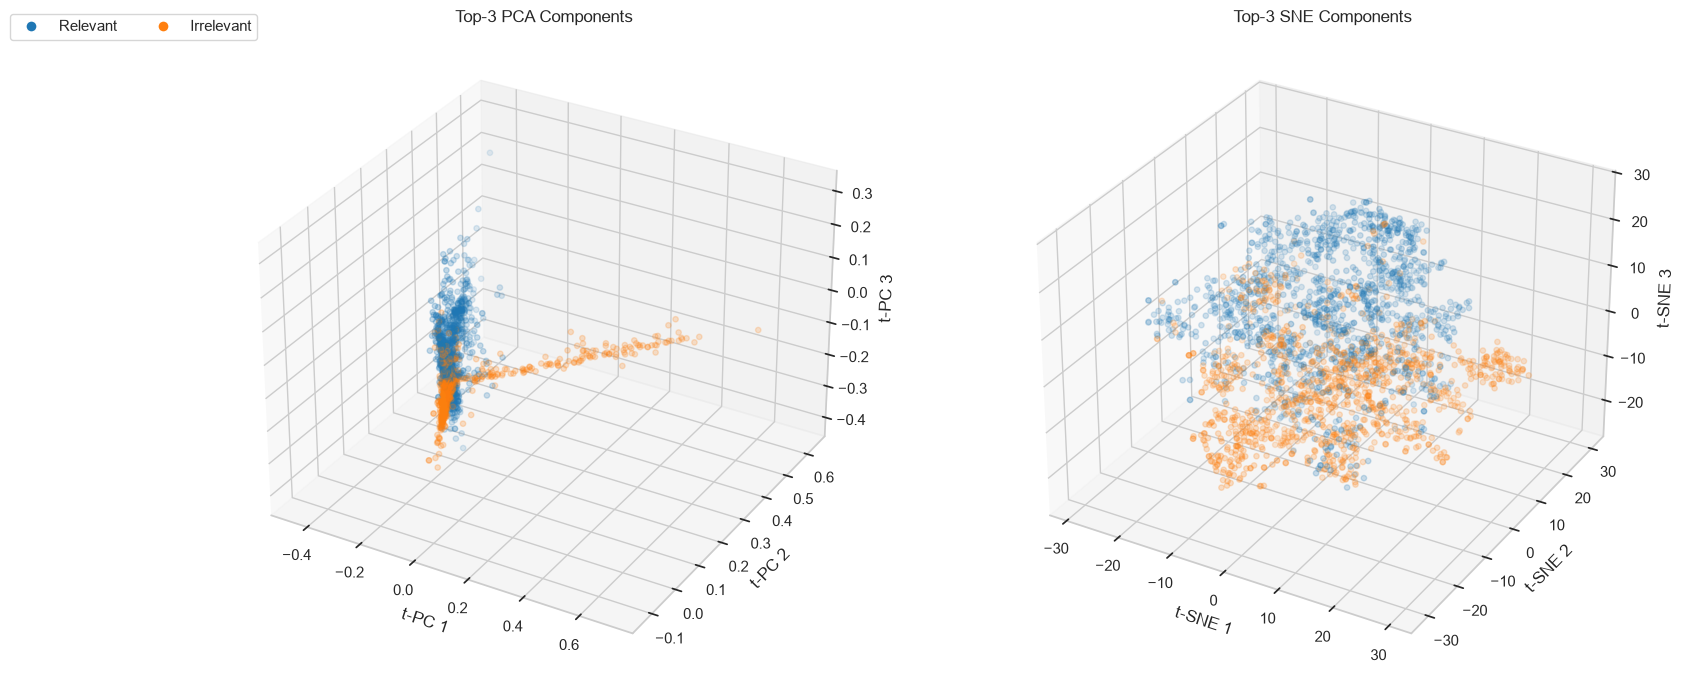

In [40]:
# Compute 3-component PCA
pca_3 = PCA(n_components=3, random_state=42)
X_pca_3 = pca_3.fit_transform(X_all)

# Compute 3-component t-SNE on PCA-50
tsne_3 = TSNE(n_components=3, perplexity=30, random_state=42, init='pca', learning_rate='auto')
X_tsne_3 = tsne_3.fit_transform(X_pca_50)

# Create 3D comparative plot
fig = plt.figure(figsize=(16, 7))

labels = df_labels['label'].values
palette = {'Relevant':'tab:blue', 'Irrelevant': 'tab:orange'}
colors = [palette[l] for l in labels]

# 3D PCA Projection
ax1 = fig.add_subplot(121, projection='3d')
ax1.scatter(X_pca_3[:, 0], X_pca_3[:, 1], X_pca_3[:, 2], c=colors, alpha=0.5, s=15)
ax1.set_title('Top-3 PCA Components')
ax1.set_xlabel('t-PC 1')
ax1.set_ylabel('t-PC 2')
ax1.set_zlabel('t-PC 3')

# 3D t-SNE Projection
ax2 = fig.add_subplot(122, projection='3d')
ax2.scatter(X_tsne_3[:, 0], X_tsne_3[:, 1], X_tsne_3[:, 2], c=colors, alpha=0.5, s=15)
ax2.set_title('Top-3 SNE Components')
ax2.set_xlabel('t-SNE 1')
ax2.set_ylabel('t-SNE 2')
ax2.set_zlabel('t-SNE 3')

# Legend proxies
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0],[0], marker='o', color='w', label='Relevant', markerfacecolor='tab:blue', markersize=8),
    Line2D([0],[0], marker='o', color='w', label='Irrelevant', markerfacecolor='tab:orange', markersize=8)
]
fig.legend(handles=legend_elements, loc='upper center', ncol=2,bbox_to_anchor=(0., 0.98))

plt.tight_layout()
plt.show()

* **Strengths and Limitations**:

| Method | Strengths | Limitations |
| :--- | :--- | :--- |
| **PCA** | • Deterministic and computationally fast.<br>• Reversible projection preserving global variance.<br>• Identifies linear feature importance via loadings. | • Cannot capture non-linear relationships.<br>• Subject to the crowding problem in 2D/3D.<br>• Poor separation for sparse, complex text clusters. |
| **t-SNE**| • Uncovers non-linear manifolds and fine cluster structures.<br>• Resolves the crowding problem via heavy-tailed Student-t.<br>• Produces clear visual cluster separation. | • Non-deterministic (stochastic initialisation).<br>• Computationally slow ($O(N^2)$ without pre-reduction).<br>• Non-reversible (cannot map new unseen data).<br>• Does not preserve global distances or densities accurately. |